In [1]:
# 03_model_comparison
#
# 목적: LightGBM(01~02단계 완료) 외 4개 모델(XGBoost, CatBoost, RandomForest, Logistic Regression)을
#      같은 train/valid/test split으로 학습해 성능을 비교한다.
#
# 원칙 (기존 단계와 동일):
#   - test는 최종 평가에만 사용, threshold는 valid의 F1-최적점을 그대로 test에 적용
#   - 원-핫 인코더/스케일러는 train으로만 fit
#   - 이번 비교 단계는 Optuna 풀 튜닝 없이 합리적 기본값 + early stopping으로 기준선만 확보
#
# 범주형 처리:
#   - LightGBM/XGBoost/CatBoost: 네이티브 카테고리 처리
#   - RandomForest/LogisticRegression: 원-핫 인코딩 (train fit) + LogisticRegression만 StandardScaler 추가
#
# 입력: data/processed/model_table_final.csv, models/lightgbm_final.txt (기존 결과 재사용)
# 출력: models/{xgboost,catboost,randomforest,logreg}_final.*, models/model_comparison.csv

In [2]:
import json
import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, log_loss, average_precision_score,
    precision_recall_curve, precision_recall_fscore_support, confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid", {"grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
})
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]

CATEGORICAL_COLS = ["city", "registered_via", "gender"]
DROP_COLS = ["msno", "snapshot", "split", "is_churn"]
RANDOM_STATE = 42

In [3]:
df = pd.read_csv(PROCESSED_DIR / "model_table_final.csv")
# city/registered_via가 CSV round-trip 과정에서 float64로 저장돼 있음 -> XGBoost의 카테고리 처리는
# float 카테고리 코드를 거부하므로 int로 캐스팅한 뒤 category로 변환한다.
df["city"] = df["city"].astype("int64").astype("category")
df["registered_via"] = df["registered_via"].astype("int64").astype("category")
df["gender"] = df["gender"].astype("category")

FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]
NUMERIC_COLS = [c for c in FEATURE_COLS if c not in CATEGORICAL_COLS]

train_df = df[df["split"] == "train"]
valid_df = df[df["split"] == "valid"]
test_df = df[df["split"] == "test"]

X_train, y_train = train_df[FEATURE_COLS], train_df["is_churn"]
X_valid, y_valid = valid_df[FEATURE_COLS], valid_df["is_churn"]
X_test, y_test = test_df[FEATURE_COLS], test_df["is_churn"]

print(f"train {len(train_df):,} / valid {len(valid_df):,} / test {len(test_df):,}")
print(f"피처 {len(FEATURE_COLS)}개 (범주형 {len(CATEGORICAL_COLS)}, 수치형 {len(NUMERIC_COLS)})")

train 1,374,692 / valid 294,722 / test 294,477
피처 40개 (범주형 3, 수치형 37)


In [4]:
def evaluate(model_name, valid_proba, test_proba):
    """valid의 F1-최적 threshold를 구해 test에 그대로 적용, 두 split의 지표를 반환"""
    precisions, recalls, thresholds = precision_recall_curve(y_valid, valid_proba)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-12)
    best_threshold = thresholds[f1s[:-1].argmax()]

    rows = []
    for split_name, y_true, proba in [("valid", y_valid, valid_proba), ("test", y_test, test_proba)]:
        pred_label = (proba >= best_threshold).astype(int)
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, pred_label, average="binary")
        rows.append({
            "model": model_name,
            "split": split_name,
            "auc": roc_auc_score(y_true, proba),
            "pr_auc": average_precision_score(y_true, proba),
            "logloss": log_loss(y_true, proba),
            "threshold": best_threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })
    return rows


results = []

In [5]:
# LightGBM: 02단계에서 저장한 모델을 재사용 (재학습 없음)
lgb_model = lgb.Booster(model_file=str(MODELS_DIR / "lightgbm_final.txt"))
lgb_valid_proba = lgb_model.predict(X_valid)
lgb_test_proba = lgb_model.predict(X_test)
results += evaluate("LightGBM", lgb_valid_proba, lgb_test_proba)
print("LightGBM 평가 완료 (기존 모델 재사용)")

LightGBM 평가 완료 (기존 모델 재사용)


In [6]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    enable_categorical=True,
    scale_pos_weight=scale_pos_weight,
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    early_stopping_rounds=50,
    random_state=RANDOM_STATE,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=100)

xgb_valid_proba = xgb_model.predict_proba(X_valid)[:, 1]
xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]
results += evaluate("XGBoost", xgb_valid_proba, xgb_test_proba)

xgb_model.save_model(str(MODELS_DIR / "xgboost_final.json"))
print(f"best_iteration: {xgb_model.best_iteration}")

[0]	validation_0-auc:0.91060


[100]	validation_0-auc:0.93648


[200]	validation_0-auc:0.93967


[300]	validation_0-auc:0.94096


[400]	validation_0-auc:0.94157


[500]	validation_0-auc:0.94172


[600]	validation_0-auc:0.94183


[700]	validation_0-auc:0.94189


[738]	validation_0-auc:0.94182


best_iteration: 688


In [7]:
X_train_cb = X_train.copy()
X_valid_cb = X_valid.copy()
X_test_cb = X_test.copy()
for c in CATEGORICAL_COLS:
    X_train_cb[c] = X_train_cb[c].astype(str)
    X_valid_cb[c] = X_valid_cb[c].astype(str)
    X_test_cb[c] = X_test_cb[c].astype(str)

cat_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    random_seed=RANDOM_STATE,
    early_stopping_rounds=50,
    verbose=200,
)
cat_model.fit(X_train_cb, y_train, eval_set=(X_valid_cb, y_valid), cat_features=CATEGORICAL_COLS)

cat_valid_proba = cat_model.predict_proba(X_valid_cb)[:, 1]
cat_test_proba = cat_model.predict_proba(X_test_cb)[:, 1]
results += evaluate("CatBoost", cat_valid_proba, cat_test_proba)

cat_model.save_model(str(MODELS_DIR / "catboost_final.cbm"))
print(f"best_iteration: {cat_model.get_best_iteration()}")

0:	test: 0.8955659	best: 0.8955659 (0)	total: 927ms	remaining: 30m 53s


200:	test: 0.9365129	best: 0.9365129 (200)	total: 2m 27s	remaining: 21m 57s


400:	test: 0.9397310	best: 0.9397310 (400)	total: 4m 47s	remaining: 19m 7s


600:	test: 0.9408056	best: 0.9408056 (600)	total: 7m 14s	remaining: 16m 50s


800:	test: 0.9413102	best: 0.9413179 (795)	total: 9m 40s	remaining: 14m 28s


1000:	test: 0.9416885	best: 0.9416893 (996)	total: 12m 6s	remaining: 12m 4s


1200:	test: 0.9419139	best: 0.9419139 (1200)	total: 14m 26s	remaining: 9m 36s


1400:	test: 0.9420177	best: 0.9420267 (1372)	total: 16m 53s	remaining: 7m 13s


Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9420267288
bestIteration = 1372

Shrink model to first 1373 iterations.


best_iteration: 1372


In [8]:
# RandomForest / LogisticRegression용: 원-핫 인코더는 train으로만 fit
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(X_train[CATEGORICAL_COLS])

def to_ohe_matrix(X):
    ohe = encoder.transform(X[CATEGORICAL_COLS])
    ohe_cols = encoder.get_feature_names_out(CATEGORICAL_COLS)
    return np.hstack([X[NUMERIC_COLS].to_numpy(dtype="float64"), ohe]), list(NUMERIC_COLS) + list(ohe_cols)

X_train_ohe, ohe_feature_names = to_ohe_matrix(X_train)
X_valid_ohe, _ = to_ohe_matrix(X_valid)
X_test_ohe, _ = to_ohe_matrix(X_test)

print(f"원-핫 인코딩 후 피처 수: {X_train_ohe.shape[1]}")

원-핫 인코딩 후 피처 수: 68


In [9]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=50,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_model.fit(X_train_ohe, y_train)

rf_valid_proba = rf_model.predict_proba(X_valid_ohe)[:, 1]
rf_test_proba = rf_model.predict_proba(X_test_ohe)[:, 1]
results += evaluate("RandomForest", rf_valid_proba, rf_test_proba)
print("RandomForest 학습 완료")

RandomForest 학습 완료


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ohe)
X_valid_scaled = scaler.transform(X_valid_ohe)
X_test_scaled = scaler.transform(X_test_ohe)

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    C=1.0,
    solver="lbfgs",
    random_state=RANDOM_STATE,
)
lr_model.fit(X_train_scaled, y_train)

lr_valid_proba = lr_model.predict_proba(X_valid_scaled)[:, 1]
lr_test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
results += evaluate("LogisticRegression", lr_valid_proba, lr_test_proba)
print("LogisticRegression 학습 완료")

LogisticRegression 학습 완료


In [11]:
import pickle

with open(MODELS_DIR / "randomforest_final.pkl", "wb") as f:
    pickle.dump(rf_model, f)
with open(MODELS_DIR / "logreg_final.pkl", "wb") as f:
    pickle.dump(lr_model, f)
with open(MODELS_DIR / "ohe_scaler.pkl", "wb") as f:
    pickle.dump({"encoder": encoder, "scaler": scaler, "numeric_cols": NUMERIC_COLS, "categorical_cols": CATEGORICAL_COLS}, f)

print("RandomForest/LogisticRegression/인코더 저장 완료")

RandomForest/LogisticRegression/인코더 저장 완료


In [12]:
results_df = pd.DataFrame(results)
results_df.to_csv(MODELS_DIR / "model_comparison.csv", index=False)

test_results = results_df[results_df["split"] == "test"].set_index("model")
test_results[["auc", "pr_auc", "logloss", "precision", "recall", "f1"]].round(4)

,auc,pr_auc,logloss,precision,recall,f1
model,,,,,,
LightGBM,0.9434,0.7571,0.1238,0.6905,0.6955,0.6929
XGBoost,0.9420,0.7479,0.2695,0.6738,0.6939,0.6837
CatBoost,0.9422,0.7441,0.2768,0.6689,0.6967,0.6825
RandomForest,0.9337,0.7142,0.3006,0.6709,0.6556,0.6631
LogisticRegression,0.8902,0.5543,0.3948,0.5290,0.5833,0.5548


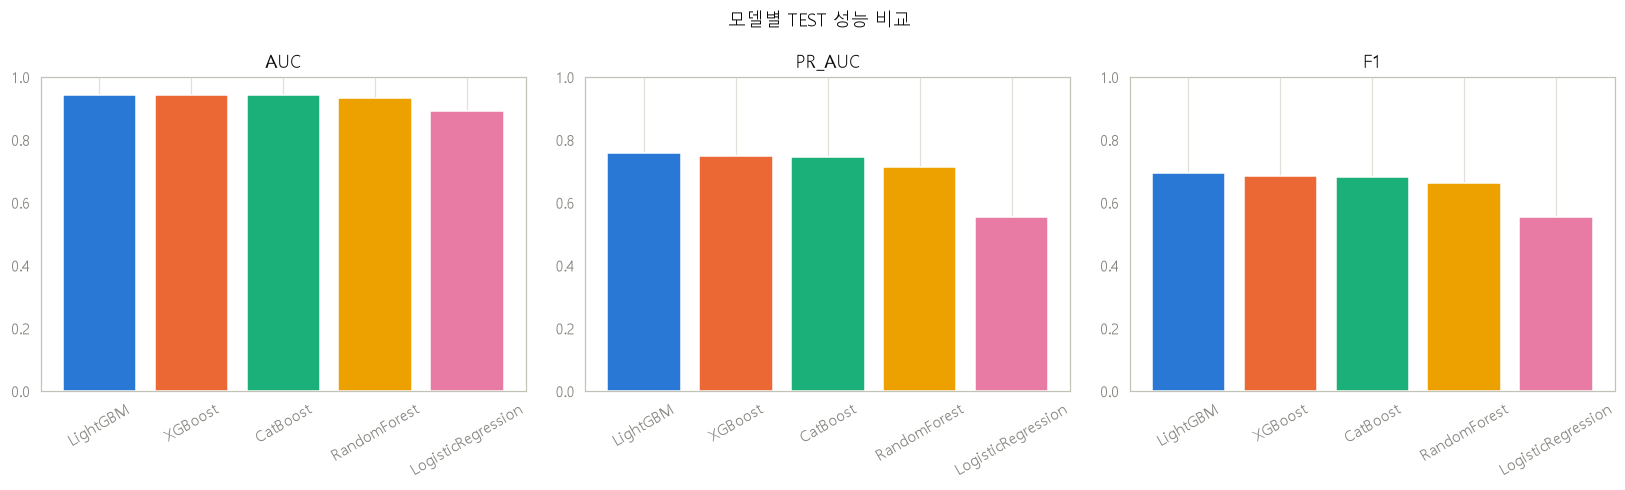

In [13]:
metrics_to_plot = ["auc", "pr_auc", "f1"]
models_order = test_results.index.tolist()

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(15, 4.5))
for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(models_order, test_results.loc[models_order, metric], color=PALETTE[: len(models_order)])
    ax.set_title(metric.upper())
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y")
    ax.set_axisbelow(True)

fig.suptitle("모델별 TEST 성능 비교")
plt.tight_layout()
plt.show()